### Blob detection

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Loading image and converting to grayscale
im_bgr = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
im_gray = cv.cvtColor(im_bgr, cv.COLOR_BGR2GRAY).astype(np.float32) / 255.0

h, w = im_gray.shape

# Selecting a sigma range
sigma_min, sigma_max, sigma_step = 1, 20, 0.5
sigmas = np.arange(sigma_min, sigma_max + sigma_step, sigma_step)
print(f"\nSigma range: [{sigma_min}, {sigma_max}]")
print(f"Number of scales: {len(sigmas)}")

scale_space = np.zeros((h, w, len(sigmas)), dtype=np.float32)

def non_maximum_suppression(image, threshold=0.03):
    suppressed = np.zeros_like(image)
    for i in range(1, image.shape[0] - 1):
        for j in range(1, image.shape[1] - 1):
            local_patch = image[i-1:i+2, j-1:j+2]
            if image[i, j] == np.max(local_patch) and image[i, j] > threshold:
                suppressed[i, j] = image[i, j]
    return suppressed

for i, sigma in enumerate(sigmas):

    hw = round(3 * sigma)
    X, Y = np.meshgrid(np.arange(-hw, hw + 1), np.arange(-hw, hw + 1))
    # Laplacian of Gaussian filter
    LoG = (X**2 + Y**2 - 2 * sigma**2) * np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    LoG /= 2 * np.pi * sigma**6

    # Normalizing the filter
    LoG *= sigma**2

    # Applying the filter
    im_LoG = cv.filter2D(im_gray, -1, LoG)

    # Storing the result in the scale space
    scale_space[:, :, i] = np.abs(im_LoG)

    # Non-maximum suppression
    suppressed = non_maximum_suppression(im_LoG)



Image shape: (360, 360, 3)
Grayscale shape: (360, 360)

Sigma range: [1, 10]
Number of scales: 37

Building scale space...
  Processed 5/37 scales
  Processed 10/37 scales
  Processed 15/37 scales
  Processed 20/37 scales
  Processed 25/37 scales
  Processed 30/37 scales
  Processed 35/37 scales

Detecting scale-space extrema...
Detection threshold: 0.0032 (max response: 0.3956)
Found 9046 blobs

Applying non-maximum suppression...
Blobs after NMS: 4133


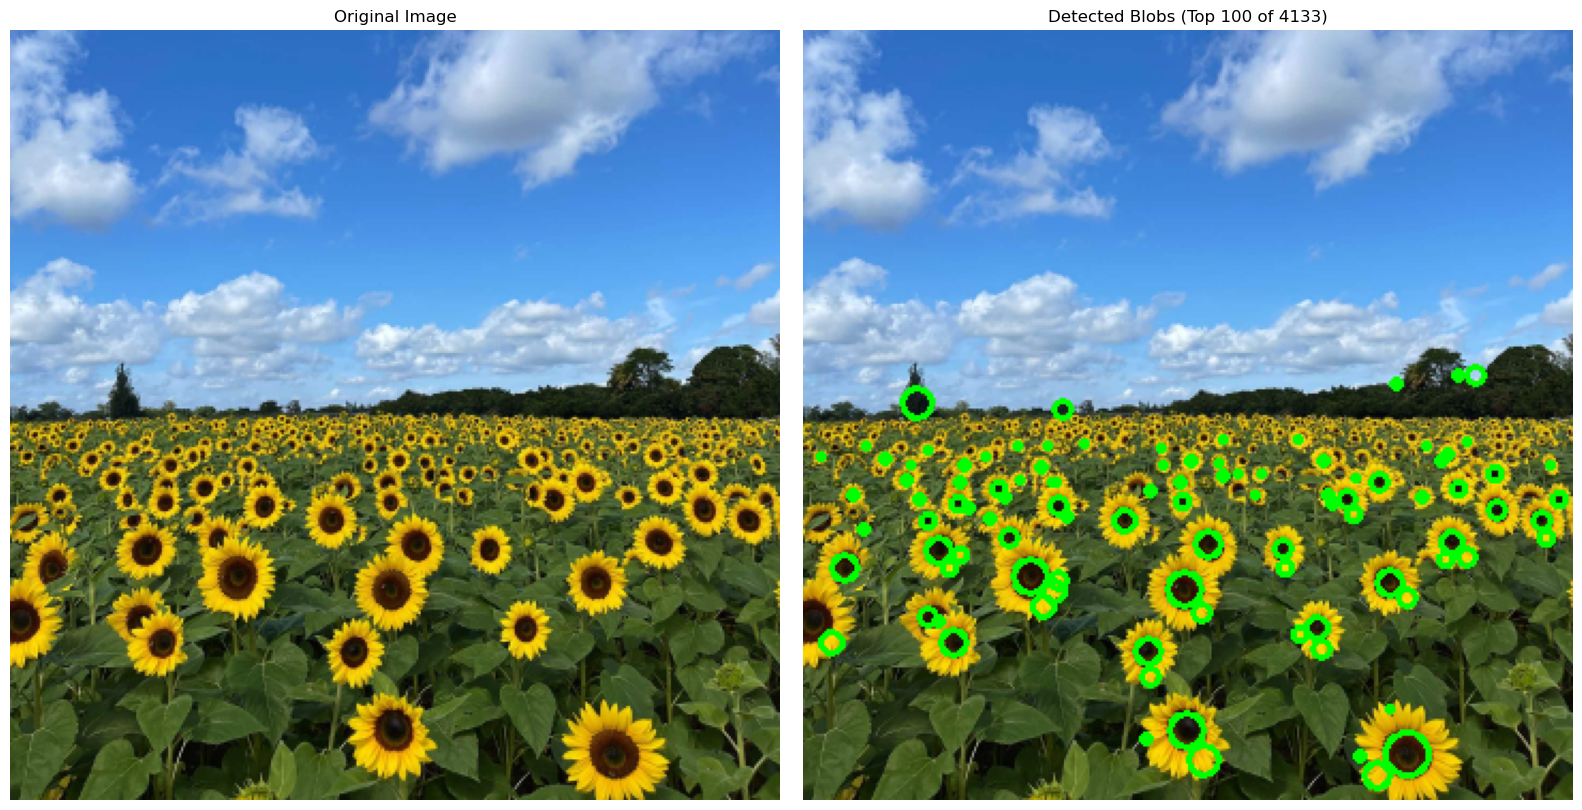


RESULTS

Sigma range used: [1.0, 10.0]
Number of scales: 37
Total blobs detected (after NMS): 4133

Top 10 Largest Circles (by sigma):
Rank   Y        X        Sigma      Radius     Response    
----------------------------------------------------------------------
1      48.0     121.0    9.50       13.44      0.1680      
2      166.0    33.0     9.50       13.44      0.1676      
3      157.0    201.0    9.50       13.44      0.1639      
4      24.0     220.0    9.50       13.44      0.1559      
5      69.0     24.0     9.50       13.44      0.1483      
6      18.0     287.0    9.50       13.44      0.0943      
7      159.0    335.0    9.25       13.08      0.1940      
8      326.0    144.0    9.25       13.08      0.1548      
9      302.0    192.0    9.25       13.08      0.1026      
10     94.0     18.0     9.25       13.08      0.0565      

Largest circle parameters:
  Center: (x=121.0, y=48.0)
  Sigma: 9.50
  Radius: 13.44 pixels
  Response strength: 0.1680

Creating zo

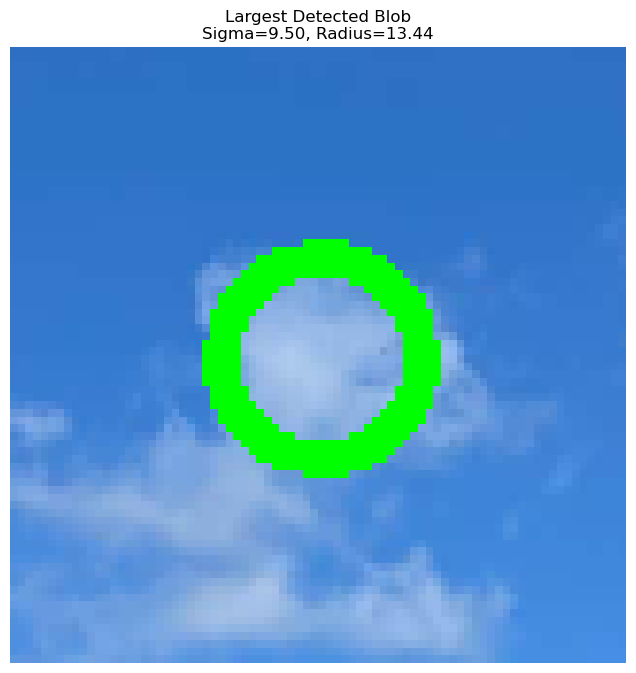


Visualization saved!


In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Loading image and converting to grayscale
im_bgr = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
im_gray = cv.cvtColor(im_bgr, cv.COLOR_BGR2GRAY).astype(np.float32) / 255.0

h, w = im_gray.shape
print(f"Image shape: {im_bgr.shape}")
print(f"Grayscale shape: {im_gray.shape}")

# Selecting a sigma range
sigma_min, sigma_max, sigma_step = 1, 10, 0.25
sigmas = np.arange(sigma_min, sigma_max + sigma_step, sigma_step)
print(f"\nSigma range: [{sigma_min}, {sigma_max}]")
print(f"Number of scales: {len(sigmas)}")

scale_space = np.zeros((h, w, len(sigmas)), dtype=np.float32)

# Build scale space
print("\nBuilding scale space...")
for i, sigma in enumerate(sigmas):
    hw = round(3 * sigma)
    X, Y = np.meshgrid(np.arange(-hw, hw + 1), np.arange(-hw, hw + 1))
    
    # Laplacian of Gaussian filter
    LoG = (X**2 + Y**2 - 2 * sigma**2) * np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    LoG /= 2 * np.pi * sigma**6
    
    # Normalizing the filter by sigma^2
    LoG *= sigma**2
    
    # Applying the filter
    im_LoG = cv.filter2D(im_gray, -1, LoG)
    
    # Storing the absolute value in the scale space
    scale_space[:, :, i] = np.abs(im_LoG)
    
    if (i + 1) % 5 == 0:
        print(f"  Processed {i + 1}/{len(sigmas)} scales")

# Detect scale-space extrema
print("\nDetecting scale-space extrema...")

def detect_scale_space_extrema(scale_space, sigmas, threshold=0.01):
    h, w, num_scales = scale_space.shape
    blobs = []
    
    # Threshold based on maximum response
    max_response = np.max(scale_space)
    abs_threshold = threshold * max_response
    print(f"Detection threshold: {abs_threshold:.4f} (max response: {max_response:.4f})")

    for scale_idx in range(1, num_scales - 1):
        current_scale = scale_space[:, :, scale_idx]
        prev_scale = scale_space[:, :, scale_idx - 1]
        next_scale = scale_space[:, :, scale_idx + 1]
        
        for i in range(1, h - 1):
            for j in range(1, w - 1):
                center_val = current_scale[i, j]
                
                if center_val < abs_threshold:
                    continue
                
                spatial_patch = current_scale[i-1:i+2, j-1:j+2]
                if center_val != np.max(spatial_patch):
                    continue
                
                if center_val <= prev_scale[i, j] or center_val <= next_scale[i, j]:
                    continue
                
                sigma = sigmas[scale_idx]
                blobs.append((i, j, sigma, center_val))
    
    return blobs

blobs = detect_scale_space_extrema(scale_space, sigmas, threshold=0.008)
print(f"Found {len(blobs)} blobs")

print("\nApplying non-maximum suppression...")

def non_maximum_suppression_blobs(blobs, overlap_threshold=0.5):
    blobs_sorted = sorted(blobs, key=lambda b: b[3], reverse=True)
    
    suppressed = []
    
    while len(blobs_sorted) > 0:
        # Take the strongest blob
        current = blobs_sorted[0]
        suppressed.append(current)
        
        y1, x1, sigma1, response1 = current
        radius1 = np.sqrt(2) * sigma1
        
        remaining = []
        for blob in blobs_sorted[1:]:
            y2, x2, sigma2, response2 = blob
            radius2 = np.sqrt(2) * sigma2
            
            # Calculate distance between centers
            distance = np.sqrt((y1 - y2)**2 + (x1 - x2)**2)
            
            # Calculate overlap
            sum_radii = radius1 + radius2
            overlap = 1 - (distance / sum_radii)
            
            # Keep if not overlapping significantly
            if overlap < overlap_threshold:
                remaining.append(blob)
        
        blobs_sorted = remaining
    
    return suppressed

blobs_nms = non_maximum_suppression_blobs(blobs, overlap_threshold=0.5)
print(f"Blobs after NMS: {len(blobs_nms)}")

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Original image
axes[0].imshow(cv.cvtColor(im_bgr, cv.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')

# Image with detected circles
result = im_bgr.copy()
num_to_draw = min(100, len(blobs_nms))
for i in range(num_to_draw):
    y, x, sigma, response = blobs_nms[i]
    
    # Radius = sqrt(2) * sigma for LoG
    radius = int(np.sqrt(2) * sigma)
    center = (int(x), int(y))
    
    # Draw circle
    cv.circle(result, center, radius, (0, 255, 0), 2)

axes[1].imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
axes[1].set_title(f'Detected Blobs (Top {num_to_draw} of {len(blobs_nms)})')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('sunflower_blob_detection.png', dpi=150, bbox_inches='tight')
plt.show()

# Report results
print("\n" + "="*70)
print("RESULTS")
print("="*70)
print(f"\nSigma range used: [{sigmas[0]}, {sigmas[-1]}]")
print(f"Number of scales: {len(sigmas)}")
print(f"Total blobs detected (after NMS): {len(blobs_nms)}")

print("\nTop 10 Largest Circles (by sigma):")
print(f"{'Rank':<6} {'Y':<8} {'X':<8} {'Sigma':<10} {'Radius':<10} {'Response':<12}")
print("-" * 70)

# Sort by sigma (size) for largest circles
blobs_by_size = sorted(blobs_nms, key=lambda b: b[2], reverse=True)

for i in range(min(10, len(blobs_by_size))):
    y, x, sigma, response = blobs_by_size[i]
    radius = np.sqrt(2) * sigma
    print(f"{i+1:<6} {y:<8.1f} {x:<8.1f} {sigma:<10.2f} {radius:<10.2f} {response:<12.4f}")

print("\nLargest circle parameters:")
y, x, sigma, response = blobs_by_size[0]
radius = np.sqrt(2) * sigma
print(f"  Center: (x={x:.1f}, y={y:.1f})")
print(f"  Sigma: {sigma:.2f}")
print(f"  Radius: {radius:.2f} pixels")
print(f"  Response strength: {response:.4f}")

# Zoomed view of largest blob
print("\nCreating zoomed view of largest blob...")
y_int, x_int = int(y), int(x)
crop_size = int(radius * 3)
y1 = max(0, y_int - crop_size)
y2 = min(h, y_int + crop_size)
x1 = max(0, x_int - crop_size)
x2 = min(w, x_int + crop_size)

cropped = im_bgr[y1:y2, x1:x2].copy()
center_in_crop = (x_int - x1, y_int - y1)
cv.circle(cropped, center_in_crop, int(radius), (0, 255, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(cv.cvtColor(cropped, cv.COLOR_BGR2RGB))
plt.title(f'Largest Detected Blob\nSigma={sigma:.2f}, Radius={radius:.2f}')
plt.axis('off')
plt.savefig('largest_blob_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved!")

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def gaussian_kernel(size, sigma):
    ax = np.arange(-size // 2 + 1, size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)



Image shape: (360, 360, 3)
Grayscale shape: (360, 360)
Computing LoG responses for 25 scales...
Sigma range: [3.00, 30.00]
  Processed 5/25 scales
  Processed 10/25 scales
  Processed 15/25 scales
  Processed 20/25 scales
  Processed 25/25 scales

Detecting scale-space extrema...
Detection threshold: 0.00 (max response: 0.39)
Found 957 blobs

Applying non-maximum suppression...
Blobs after NMS: 453


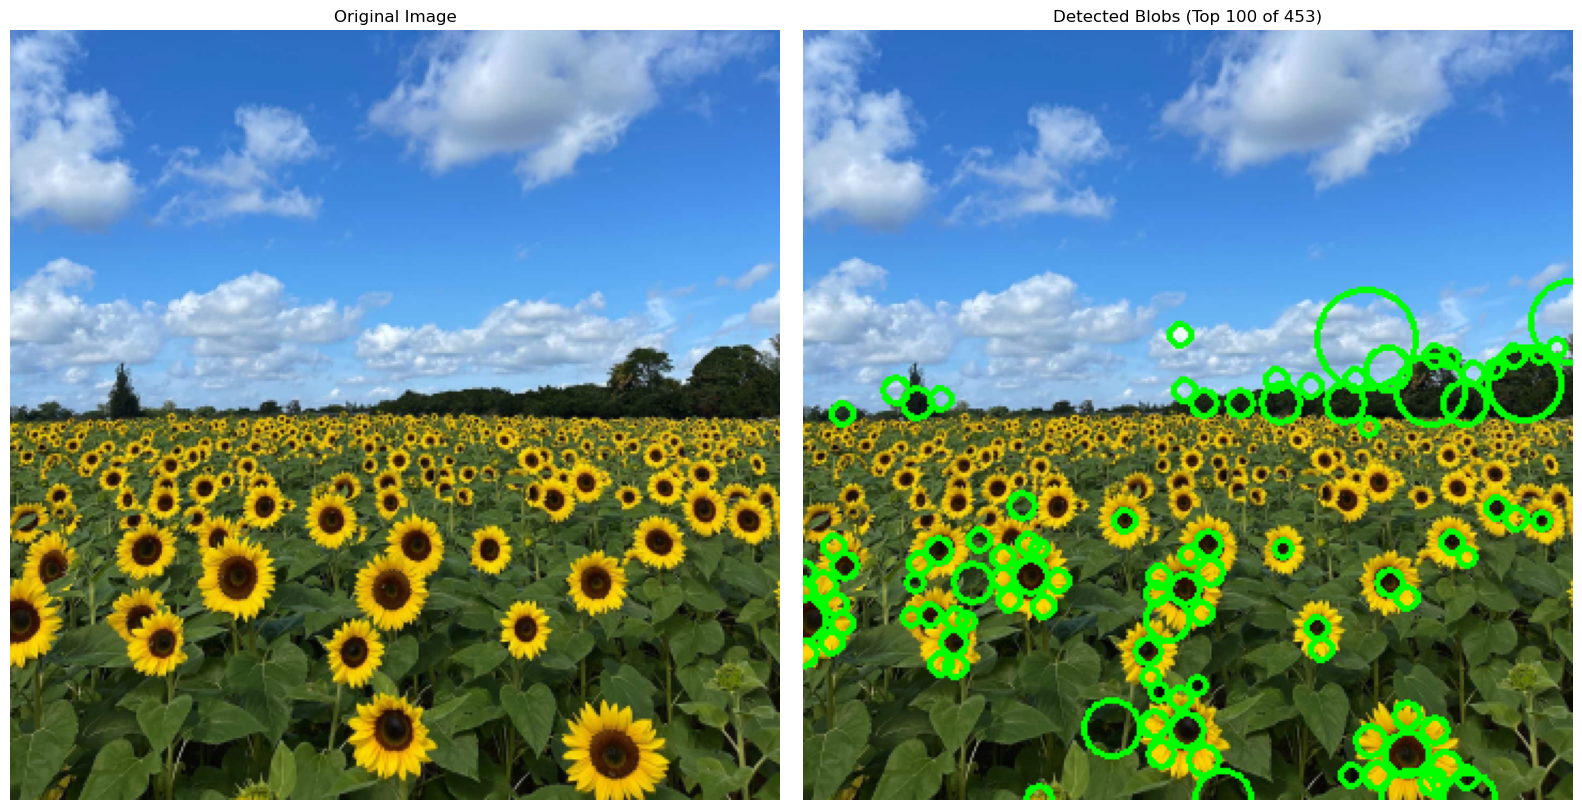


RESULTS

Sigma range used: [3.00, 30.00]
Number of scales: 25

Total blobs detected (after NMS): 453

Top 10 Largest Circles:
Rank   Y        X        Sigma      Radius     Response    
------------------------------------------------------------
1      239.0    303.0    4.00       5.66       0.3810      
2      279.0    240.0    3.63       5.14       0.3808      
3      242.0    224.0    3.30       4.67       0.3806      
4      229.0    345.0    3.30       4.67       0.3782      
5      229.0    150.0    4.00       5.66       0.3672      
6      223.0    324.0    3.63       5.14       0.3663      
7      290.0    161.0    4.40       6.23       0.3637      
8      255.0    106.0    5.87       8.30       0.3633      
9      240.0    189.0    4.40       6.23       0.3626      
10     243.0    63.0     4.40       6.23       0.3568      

Largest circle parameters:
  Center: (303.0, 239.0)
  Sigma: 4.00
  Radius: 5.66 pixels
  Response strength: 0.3810

Creating zoomed view of largest bl

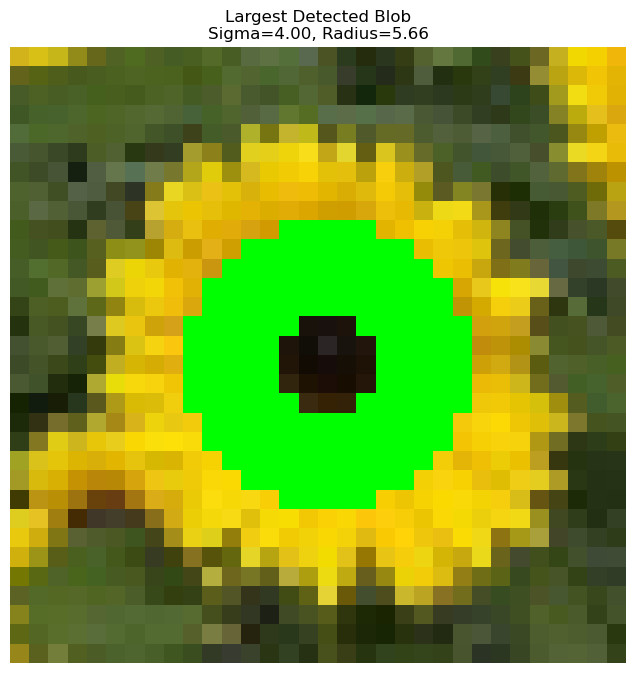


Visualization saved as 'sunflower_blob_detection.png' and 'largest_blob_zoom.png'


In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

def compute_log_response(image, sigma):
    """
    Compute Laplacian of Gaussian response for a given sigma.
    Scale-normalize by sigma^2 for scale invariance.
    """
    # Apply Gaussian smoothing
    smoothed = ndimage.gaussian_filter(image, sigma)
    
    # Compute Laplacian using the Laplacian operator
    log_response = ndimage.laplace(smoothed)
    
    # Scale normalization: multiply by sigma^2 for scale invariance
    log_response = (sigma ** 2) * log_response
    
    return np.abs(log_response)

def detect_blobs_log(image, sigma_min=5, sigma_max=50, num_scales=20, threshold=0.01):
    """
    Detect blobs using Laplacian of Gaussian across multiple scales.
    
    Parameters:
    - image: Input grayscale image
    - sigma_min: Minimum sigma value
    - sigma_max: Maximum sigma value
    - num_scales: Number of scales to check
    - threshold: Threshold for blob detection (relative to max response)
    
    Returns:
    - blobs: List of (y, x, sigma) tuples
    """
    # Generate sigma values (logarithmically spaced for scale-space)
    sigma_values = np.logspace(np.log10(sigma_min), np.log10(sigma_max), num_scales)
    
    # Store LoG responses for all scales
    log_responses = []
    
    print(f"Computing LoG responses for {num_scales} scales...")
    print(f"Sigma range: [{sigma_min:.2f}, {sigma_max:.2f}]")
    
    for i, sigma in enumerate(sigma_values):
        log_response = compute_log_response(image, sigma)
        log_responses.append(log_response)
        if (i + 1) % 5 == 0:
            print(f"  Processed {i + 1}/{num_scales} scales")
    
    # Stack into 3D array (scale, height, width)
    log_stack = np.stack(log_responses, axis=0)
    
    # Find local maxima in scale-space
    print("\nDetecting scale-space extrema...")
    
    # Find local maxima in spatial dimensions (3x3 neighborhood)
    # and in scale dimension (compare with adjacent scales)
    blobs = []
    
    # Compute threshold as relative to maximum response
    max_response = np.max(log_stack)
    abs_threshold = threshold * max_response
    print(f"Detection threshold: {abs_threshold:.2f} (max response: {max_response:.2f})")
    
    # For each scale (except first and last)
    for scale_idx in range(1, len(sigma_values) - 1):
        # Current scale response
        current = log_stack[scale_idx]
        
        # Check if local maxima in scale direction
        scale_max = np.maximum(log_stack[scale_idx - 1], log_stack[scale_idx + 1])
        
        # Find points that are local maxima in scale
        is_scale_max = current > scale_max
        
        # Find local maxima in spatial dimensions using maximum filter
        local_max = ndimage.maximum_filter(current, size=3)
        is_spatial_max = (current == local_max)
        
        # Combine conditions: spatial max, scale max, and above threshold
        is_blob = is_spatial_max & is_scale_max & (current > abs_threshold)
        
        # Get coordinates of blobs
        y_coords, x_coords = np.where(is_blob)
        
        for y, x in zip(y_coords, x_coords):
            sigma = sigma_values[scale_idx]
            response = current[y, x]
            blobs.append((y, x, sigma, response))
    
    print(f"Found {len(blobs)} blobs")
    
    # Sort by response strength (descending)
    blobs.sort(key=lambda b: b[3], reverse=True)
    
    return blobs, sigma_values

def non_maximum_suppression(blobs, overlap_threshold=0.5):
    """
    Remove overlapping blobs using non-maximum suppression.
    """
    if len(blobs) == 0:
        return []
    
    # Convert to array for easier processing
    blobs_array = np.array([(b[0], b[1], b[2], b[3]) for b in blobs])
    
    suppressed = []
    
    while len(blobs_array) > 0:
        # Take the blob with highest response
        current = blobs_array[0]
        suppressed.append(tuple(current))
        
        if len(blobs_array) == 1:
            break
        
        # Calculate distances to all other blobs
        y1, x1, sigma1, _ = current
        y2, x2, sigma2, _ = blobs_array[1:, 0], blobs_array[1:, 1], blobs_array[1:, 2], blobs_array[1:, 3]
        
        # Euclidean distance between centers
        distances = np.sqrt((y1 - y2)**2 + (x1 - x2)**2)
        
        # Sum of radii (radius = sqrt(2) * sigma for LoG)
        radius1 = np.sqrt(2) * sigma1
        radius2 = np.sqrt(2) * sigma2
        sum_radii = radius1 + radius2
        
        # Calculate overlap (IoU-like metric)
        overlap = 1 - (distances / sum_radii)
        
        # Keep only blobs that don't overlap significantly
        keep_mask = overlap < overlap_threshold
        blobs_array = blobs_array[1:][keep_mask]
    
    return suppressed

# Load the image
im = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)

# Convert to grayscale
gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY)

print(f"Image shape: {im.shape}")
print(f"Grayscale shape: {gray.shape}")

# Normalize to [0, 1]
gray_normalized = gray.astype(np.float32) / 255.0

# Detect blobs
blobs, sigma_values = detect_blobs_log(
    gray_normalized,
    sigma_min=3,
    sigma_max=30,
    num_scales=25,
    threshold=0.005
)

# Apply non-maximum suppression
print("\nApplying non-maximum suppression...")
blobs_nms = non_maximum_suppression(blobs, overlap_threshold=0.5)
print(f"Blobs after NMS: {len(blobs_nms)}")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Original image
axes[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')

# Image with detected circles
result = im.copy()
for i, (y, x, sigma, response) in enumerate(blobs_nms[:100]):  # Draw top 100
    # Radius = sqrt(2) * sigma for LoG
    radius = int(np.sqrt(2) * sigma)
    center = (int(x), int(y))
    
    # Draw circle (green for sunflowers)
    cv.circle(result, center, radius, (0, 255, 0), 2)

axes[1].imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
axes[1].set_title(f'Detected Blobs (Top 100 of {len(blobs_nms)})')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('sunflower_blob_detection.png', dpi=150, bbox_inches='tight')
plt.show()

# Report parameters of largest circles
print("\n" + "="*60)
print("RESULTS")
print("="*60)
print(f"\nSigma range used: [{sigma_values[0]:.2f}, {sigma_values[-1]:.2f}]")
print(f"Number of scales: {len(sigma_values)}")
print(f"\nTotal blobs detected (after NMS): {len(blobs_nms)}")

print("\nTop 10 Largest Circles:")
print(f"{'Rank':<6} {'Y':<8} {'X':<8} {'Sigma':<10} {'Radius':<10} {'Response':<12}")
print("-" * 60)

for i, (y, x, sigma, response) in enumerate(blobs_nms[:10]):
    radius = np.sqrt(2) * sigma
    print(f"{i+1:<6} {y:<8.1f} {x:<8.1f} {sigma:<10.2f} {radius:<10.2f} {response:<12.4f}")

print("\nLargest circle parameters:")
y, x, sigma, response = blobs_nms[0]
radius = np.sqrt(2) * sigma
print(f"  Center: ({x:.1f}, {y:.1f})")
print(f"  Sigma: {sigma:.2f}")
print(f"  Radius: {radius:.2f} pixels")
print(f"  Response strength: {response:.4f}")

# Create a zoomed-in view of the largest blob
print("\nCreating zoomed view of largest blob...")
y_int, x_int = int(y), int(x)
crop_size = int(radius * 3)
y1 = max(0, y_int - crop_size)
y2 = min(im.shape[0], y_int + crop_size)
x1 = max(0, x_int - crop_size)
x2 = min(im.shape[1], x_int + crop_size)

cropped = im[y1:y2, x1:x2].copy()
center_in_crop = (x_int - x1, y_int - y1)
cv.circle(cropped, center_in_crop, int(radius), (0, 255, 0), 3)

plt.figure(figsize=(8, 8))
plt.imshow(cv.cvtColor(cropped, cv.COLOR_BGR2RGB))
plt.title(f'Largest Detected Blob\nSigma={sigma:.2f}, Radius={radius:.2f}')
plt.axis('off')
plt.savefig('largest_blob_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'sunflower_blob_detection.png' and 'largest_blob_zoom.png'")